In [1]:
import numpy as np
import pandas as pd
import glob
import os
import random
import matplotlib.pyplot as plt

In [2]:
ms = [0, 25,50,75,100,175,275,475,750,1225,2000]
frames = [0,3,6,9,12,21,33,57,90,147,240]
frames_ms_mapping = {key: val for key, val in zip(frames, ms)}
frames_ms_mapping

{0: 0,
 3: 25,
 6: 50,
 9: 75,
 12: 100,
 21: 175,
 33: 275,
 57: 475,
 90: 750,
 147: 1225,
 240: 2000}

In [3]:
## grab files
directory = 'optseq2_design_ok'
# pattern = 'tr-200_min-3_nsearch-1000*.par'
pattern = 'design_12cond_focb_ok-*.par'
texture_id = [i for i in range(160)] # there are 160 density-4 snakes
target_directory = 'trial_sequences'
# define mapping frames to ms
# frames_ms_mapping = {0 : 0, 2 : 17, 4 : 33, 8 : 67, 16 : 134, 32 : 267, 64 : 533}
ms = [0, 25,50,75,100,175,275,475,750,1225,2000]
frames = [0,3,6,9,12,21,33,57,90,147,240]
frames_ms_mapping = {frame: ms for frame, ms in zip(frames, ms)}

frames = [0,3,6,9,12,21,33,57,90,147,240]

dur_idx_frames_mapping = {idx : frame for idx, frame in zip(range(12), [0] + frames)}

files = glob.glob(os.path.join(directory, pattern))
files.sort()

plot = False
if plot:
    fig, axs = plt.subplots(3,5, figsize=(15,9))

# print(files)
for j, file in enumerate(files):

    with open(file, 'r') as f:
        lines = f.readlines()

    rows = []
    for line in lines:
        split_line = line.split(' ')
        vals = [val.strip() for val in split_line if (val != '') & (val != '\n')]
        for i in range(len(vals)-1):
            vals[i] = np.round(float(vals[i]), 2)
        
        # adding 0s to itis
        if vals[-1] == 'NULL':
            rows[-1][2] = np.round(rows[-1][2] + vals[2], 2)
            # uncomment to debug
    #         rows.append(vals)
        
        else:
            rows.append(vals)
    print(rows)
    iti_df = pd.DataFrame(rows, columns = ['time', 'id', 'iti_s', 'unknown', 'type'])
    iti_df['time'] = iti_df['time'].astype(float)
    iti_df['iti_s'] = iti_df['iti_s'].astype(float)
    iti_df['iti_TR'] = np.round(iti_df['iti_s']/.9).astype(int)
    iti_df['iti_TR_cum'] = np.cumsum(iti_df['iti_TR'])
    iti_df['cond_frames'] = [dur_idx_frames_mapping[int(val.split('_')[1])] for val in iti_df['type']]
    iti_df['type'] = [val.split('_')[0] for val in iti_df['type']]
    iti_df = iti_df.drop(['id', 'unknown'], axis = 1)
    iti_df['cond_ms'] = [frames_ms_mapping[val] for val in iti_df['cond_frames']]
    iti_df['phase_0_ms'] = [2000] * len(iti_df)
    iti_df['phase_0_frames'] = [240] * len(iti_df)
    iti_df['phase_1_ms'] = iti_df['iti_s'] - 2.0
    iti_df['phase_1_frames'] = (iti_df['phase_1_ms'] * 120).astype(int)
    
    
    
    random.shuffle(texture_id)
    iti_df['texture_id'] = texture_id[:len(iti_df)]

    # check
    print(iti_df.iti_TR_cum.iloc[-1])
    if plot:

        n, bins, _ = axs.flatten()[j].hist(iti_df['iti_s'])
        if j % 5 ==0:
            axs.flatten()[j].set_ylabel("counts")
        if j >= 10:
            axs.flatten()[j].set_xlabel("ITI [s]")
        
    # dot product of histogram
    # print(iti_df.iti_TR.value_counts().values @ iti_df.iti_TR.value_counts().keys().to_numpy())    
    # print(n.shape, bins.shape)
    # print(n, bins)
    
    
    # save
    try:
        os.mkdir(target_directory)
    except FileExistsError:
        pass
    path = os.path.join(target_directory, f'design_12cond_focb_ok_{file.split("-")[-1].split(".")[0]}.csv')
    iti_df.to_csv(path, index = False)
# plt.savefig('iti_hist_new_seq.png', transparent = False)

[[np.float64(0.0), np.float64(3.0), np.float64(3.6), np.float64(1.0), 'dur_2'], [np.float64(3.6), np.float64(2.0), np.float64(3.6), np.float64(1.0), 'dur_1'], [np.float64(7.2), np.float64(10.0), np.float64(3.6), np.float64(1.0), 'dur_9'], [np.float64(10.8), np.float64(3.0), np.float64(3.6), np.float64(1.0), 'dur_2'], [np.float64(14.4), np.float64(5.0), np.float64(3.6), np.float64(1.0), 'dur_4'], [np.float64(18.0), np.float64(8.0), np.float64(3.6), np.float64(1.0), 'dur_7'], [np.float64(21.6), np.float64(6.0), np.float64(3.6), np.float64(1.0), 'dur_5'], [np.float64(25.2), np.float64(1.0), np.float64(3.6), np.float64(1.0), 'dur_0'], [np.float64(28.8), np.float64(8.0), np.float64(3.6), np.float64(1.0), 'dur_7'], [np.float64(32.4), np.float64(9.0), np.float64(3.6), np.float64(1.0), 'dur_8'], [np.float64(36.0), np.float64(9.0), np.float64(3.6), np.float64(1.0), 'dur_8'], [np.float64(39.6), np.float64(3.0), np.float64(3.6), np.float64(1.0), 'dur_2'], [np.float64(43.2), np.float64(7.0), np.fl

NameError: name 'n' is not defined

In [4]:
iti_df

,time,iti_s,type,iti_TR,iti_TR_cum,cond_frames,cond_ms,texture_id
0,0.0,4.8,dur,3,3,32,267,22
1,4.8,8.0,dur,5,8,4,33,102
2,12.8,16.0,dur,10,18,32,267,6
3,28.8,9.6,dur,6,24,0,0,20
4,38.4,4.8,isi,3,27,64,533,56
5,43.2,11.2,isi,7,34,64,533,136
6,54.4,9.6,dur,6,40,16,134,36
7,64.0,4.8,dur,3,43,0,0,106
8,68.8,6.4,dur,4,47,16,134,84
9,75.2,9.6,dur,6,53,32,267,129


In [11]:
trial_types = ['_'.join([row.type, str(row.cond_ms)]) for i,row in iti_df.iterrows()]
# amps = [row.cond_frames for i,row in iti_df.iterrows()]
amps = [trials[trial_type] for trial_type in trial_types]

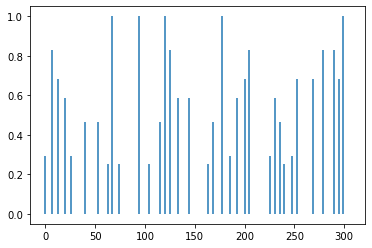

In [12]:
plt.vlines(iti_df.time, 0, amps)

In [10]:
## predicted from DN model
trials = {"dur_0" : 0,
         "dur_17" : 2.08,
         "dur_33" : 2.57,
         "dur_67" : 3.14,
         "dur_134" : 3.74,
        # "dur_267-isi_0" : 4.47,
         "dur_267" : 4.47, 
         "dur_533" : 5.54,
         "isi_17" : 4.50,
         "isi_33" : 4.53,
         "isi_67" : 4.61,
         "isi_134" : 4.80,
         "isi_267" : 5.25,
         "isi_533" : 6.21}

## from sub-04 ses 2
trials = {"dur_0" : 0,
         "dur_17" : 0.25041807,
         "dur_33" : 0.29488196,
         "dur_67" : 0.46286292,
         "dur_134" : 0.58560391,
        # "dur_267-isi_0" : 4.47,
         "dur_267" : 0.68497068, 
         "dur_533" : 1,
         "isi_17" : 0.79757369,
         "isi_33" : 0.80716185,
         "isi_67" : 0.83481767,
         "isi_134" : 0.84408676,
         "isi_267" : 0.83662058,
         "isi_533" : 0.83093261}

In [47]:
np.arange(3, 3+len(n))

array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

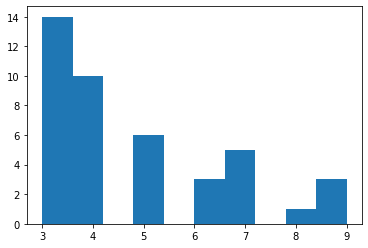

In [33]:
fig, ax = plt.subplots()
n, bar, _ = ax.hist(iti_df['iti_TR'])

In [64]:
iti_df.iti_TR.value_counts().values @ iti_df.iti_TR.value_counts().keys().to_numpy()

200

In [62]:
iti_df.iti_TR.value_counts()

3     15
4     11
7      4
5      4
6      4
8      2
13     1
10     1
Name: iti_TR, dtype: int64

Note for future optseq2 endeavours: try to make sure min of 2 or 3 trs either by increasing duration to that or by not allowing 0 as an option for NULL in between

In [48]:
rows = []
for line in lines:
    split_line = line.split(' ')
    vals = [val.strip() for val in split_line if (val != '') & (val != '\n')]
    for i in range(len(vals)-1):
        vals[i] = np.round(float(vals[i]), 2)
    
    # adding 0s to itis
    if vals[-1] == 'NULL':
        rows[-1][2] = np.round(rows[-1][2] + vals[2], 2)
        # uncomment to debug
#         rows.append(vals)
    
    else:
        rows.append(vals)
    

frames_ms_mapping = {0 : 0, 2 : 17, 4 : 33, 8 : 67, 16 : 134, 32 : 267, 64 : 533}

texture_id = [i for i in range(160)] # there are 160 density-4 snakes

random.shuffle(texture_id)

iti_df = pd.DataFrame(rows, columns = ['time', 'id', 'iti_s', 'unknown', 'type'])
iti_df['time'] = iti_df['time'].astype(float)
iti_df['iti_s'] = iti_df['iti_s'].astype(float)
iti_df['iti_TR'] = (iti_df['iti_s']/1.6).astype(int)

iti_df['cond_frames'] = [int(val.split('_')[1]) for val in iti_df['type']]
iti_df['type'] = [val.split('_')[0] for val in iti_df['type']]
iti_df = iti_df.drop(['id', 'unknown'], axis = 1)
iti_df['cond_ms'] = [frames_ms_mapping[val] for val in iti_df['cond_frames']]
iti_df['texture_id'] = texture_id[:39]

# rows
iti_df

ValueError: Length of values (39) does not match length of index (42)

In [74]:
np.histogram(iti_df['iti_s'])
iti_df['iti_s'].value_counts()

iti_s
4.8     12
6.4      8
8.0      6
9.6      3
12.8     3
11.2     3
14.4     2
16.0     1
17.6     1
Name: count, dtype: int64

In [71]:
np.histogram(iti_df['iti_s'])[0]

array([12,  8,  6,  3,  0,  3,  3,  2,  1,  1])

In [72]:
(np.arange(3, 12) *1.6)

array([ 4.8,  6.4,  8. ,  9.6, 11.2, 12.8, 14.4, 16. , 17.6])

(array([15., 11.,  8.,  0.,  4.,  2.,  0.,  1.,  0.,  1.]),
 array([ 4.8,  6.4,  8. ,  9.6, 11.2, 12.8, 14.4, 16. , 17.6, 19.2, 20.8]),
 <BarContainer object of 10 artists>)

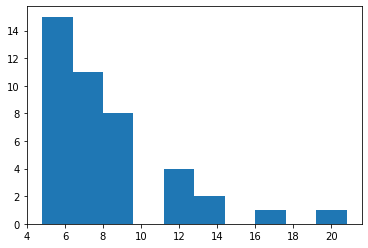

In [8]:
import matplotlib.pyplot as plt
plt.hist(iti_df['iti_s'])

In [21]:
[val for split_line in [line.split(' ') for line in lines ] if val != '']

[['',
  '',
  '0.0000',
  '',
  '',
  '',
  '4',
  '',
  '',
  '',
  '1.600',
  '',
  '',
  '1.0000',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  'dur8\n'],
 ['',
  '',
  '1.6000',
  '',
  '',
  '',
  '0',
  '',
  '',
  '11.200',
  '',
  '',
  '1.0000',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  'NULL',
  '\n'],
 ['',
  '12.8000',
  '',
  '',
  '',
  '4',
  '',
  '',
  '',
  '1.600',
  '',
  '',
  '1.0000',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  'dur8\n'],
 ['',
  '14.4000',
  '',
  '',
  '',
  '0',
  '',
  '',
  '',
  '1.600',
  '',
  '',
  '1.0000',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  'NULL',
  '\n'],
 ['',
  '16.0000',
  '',
  '',
  '',
  '1',
  '',
  '',
  '',
  '0.000',
  '',
  '',
  '1.0000',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  'dur0\n'],
 ['',
  '16.0000',
  '',
  '',
  '',
  '0',
  '',
  '',
  '',
  '3.200',
  '',
  '',
  '1.0000',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  'NULL',
  

In [19]:
lines[0].split(' ')[0] == ''

True

In [32]:


pd.read_csv('seq.txt', sep = '\t', names =['time', 'id', 'duration', 'unknown', 'type'])

,time,id,duration,unknown,type
0,0.0000 4 1.600 1.0000 dur8,NaN,NaN,NaN,NaN
1,1.6000 0 11.200 1.0000 NULL,NaN,NaN,NaN,NaN
2,12.8000 4 1.600 1.0000 dur8,NaN,NaN,NaN,NaN
3,14.4000 0 1.600 1.0000 NULL,NaN,NaN,NaN,NaN
4,16.0000 1 0.000 1.0000 dur0,NaN,NaN,NaN,NaN
...,...,...,...,...,...
68,324.8007 0 8.000 1.0000 NULL,NaN,NaN,NaN,NaN
69,332.8007 1 0.000 1.0000 dur0,NaN,NaN,NaN,NaN
70,332.8007 0 9.600 1.0000 NULL,NaN,NaN,NaN,NaN
71,342.4007 13 1.600 1.0000 isi64,NaN,NaN,NaN,NaN
